A Structured Output Agent in LangChain (or other LLM frameworks) refers to an agent that produces responses in a specific structured format, such as JSON, dictionaries, or other structured data types. These agents are particularly useful when you want to ensure that your responses conform to a defined schema, making it easier to parse, validate, and utilize in downstream applications.

Why Use a Structured Output Agent?
Controlled Responses: Ensures that the outputs follow a specific format, reducing ambiguity.
Data Validation: Useful when you want the model output to fit predefined structures, like for APIs or database entries.
Automation: Makes integration with systems like dashboards, ETL pipelines, or business workflows easier.

In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState, START
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma
from pydantic import BaseModel, Field

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()

True

In [3]:
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI()

In [4]:
from IPython.display import Image, display
def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

In [5]:
class CityDetails(BaseModel):
    """Respond to the user with this"""
    state_name: str = Field(description="State name of the city")
    state_capital: str = Field(description="State capital of the city")
    country_name: str = Field(description="Country name of the city")
    country_capital: str = Field(description="Country capital of the city")

In [6]:
model_with_structured_output = llm.with_structured_output(CityDetails)

In [7]:
# Inherit 'messages' key from MessagesState, which is a list of chat messages
class AgentState(MessagesState):
    # Final structured response from the agent
    final_response: CityDetails

In [8]:
tavily_tool = TavilySearchResults()
@tool
def get_city_details(prompt):
    "Should do a web search to find the required city details"
    response = tavily_tool.invoke(prompt)
    return response

In [9]:
tools = [get_city_details]
llm_with_tool=llm.bind_tools(tools) #Need to bind LLM with the tool so that it can take decision whether to utilize the tool or not


In [10]:
def call_model(state: AgentState):
    print("-----call_model-----")
    print(state)
    print("-----call_model-----")
    messages = state['messages']
    response = llm_with_tool.invoke(messages) #Use llm_with_tool instead of llm
    return {"messages": [response]}

In [11]:
def router(state: AgentState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return "respond"

In [12]:
def respond(state: AgentState):
    print("-----respond-----")
    print(state)
    print("-----respond-----")
    messages = state['messages']
    last_message = messages[-1]
    response = model_with_structured_output.invoke([HumanMessage(content=last_message.content)])
    return {"final_response": response}


In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))
workflow.add_node("respond", respond)

workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    
    router,
    {
        "tools": "tools",
        "respond": "respond",
    },
)

workflow.add_edge("tools", "agent")
workflow.add_edge("respond", END)
app = workflow.compile()

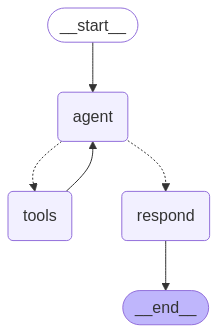

In [14]:
displayGraph(app)

In [20]:
answer = app.invoke(input={"messages": ["Tell me about the city details for Najafgarh?"]})

-----call_model-----
{'messages': [HumanMessage(content='Tell me about the city details for Najafgarh?', additional_kwargs={}, response_metadata={}, id='24605498-04a0-4ea3-9912-cf9374ed7b09')]}
-----call_model-----
-----call_model-----
{'messages': [HumanMessage(content='Tell me about the city details for Najafgarh?', additional_kwargs={}, response_metadata={}, id='24605498-04a0-4ea3-9912-cf9374ed7b09'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_HQeNBQznVfJkwPxT6WUS87z9', 'function': {'arguments': '{"prompt":"Najafgarh"}', 'name': 'get_city_details'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 63, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id'

In [21]:
answer

{'messages': [HumanMessage(content='Tell me about the city details for Najafgarh?', additional_kwargs={}, response_metadata={}, id='24605498-04a0-4ea3-9912-cf9374ed7b09'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_HQeNBQznVfJkwPxT6WUS87z9', 'function': {'arguments': '{"prompt":"Najafgarh"}', 'name': 'get_city_details'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 63, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNYiGjHVsyATSIqdOcJfBWHQbRlkr', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-922fcd19-4ee5-44c2-888e-e700a02b9bee-0', tool_calls=[{'name': 'get_city_details', 'args': {'prompt': 'Najafgarh'}, 'id': 'call_HQeNB

In [22]:
answer['final_response'] # Because final_response stores the structured output

CityDetails(state_name='Delhi', state_capital='New Delhi', country_name='India', country_capital='New Delhi')